In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
import jax
import matplotlib.pyplot as plt
import matplotlib
import sys

sys.path.append("../src")

import jax
import jax.numpy as jnp

import netket as nk
import numpy as np

from netket.operator.spin import sigmax, sigmaz
from metropolis import LocalDoubleFlipRule
from netket.experimental.dynamics import RK45, Heun
from callbacks import (
    get_acceptance_rate_callback,
    get_umbrella_monitor_callback,
    get_tdvp_monitor_callback,
    get_parameter_save_callback,
    get_overdispersed_parity_callback
)
from logger import Logger
from flax import serialization

from schmitt_tdvp_overdispersed import TDVPSchmittOverdispersed
from schmitt_tdvp import TDVPSchmitt
from schmitt_tdvp_blur import TDVPSchmittBlur

from tfim_exact_majorana import run_ed
import numpy as np
from flax import linen as nn
from gaussian_state import GaussianState

import os
import matplotlib.pyplot as plt

import sys

sys.path.append("../src")

import jax.numpy as jnp

import warnings
warnings.filterwarnings("error", category=jnp.ComplexWarning)


∣NK⟩ Tip: 😍 Love? 😡 Hate? these tips? Let us know at https://forms.gle/ej8eDGFRu2mww5mQ9

In [2]:
fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("parity", "Mean"),
    ("parity", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
    ("acceptance_rate", "values"),
)

In [3]:
class ScaledGaussianState(GaussianState):
    logpsi_scale: float = 1.0
    @nn.compact
    def __call__(self, x):
        return self.logpsi_scale * super().__call__(x)
    
def main_gaussian(N, n_samples_tvmc, driver_type, alpha, h, T, dt_, chunk_size=None, init_noise_std = 1e-5, blur_q = 0.2):
    print(N, n_samples_tvmc, driver_type, alpha, h, T)
    hilbert = nk.hilbert.Spin(s=1 / 2, N=N)

    def get_model(dtype, logpsi_scale=1.0, init_noise_std=1e-3):
        return ScaledGaussianState(
            param_dtype=dtype,
            logpsi_scale=logpsi_scale, init_noise_std=float(init_noise_std)
        )

    def get_vstates(n_samples, sampling_dtype=jnp.float64):
        

        seed = 300
        model = get_model(jnp.float64, init_noise_std= init_noise_std)
        sampler = nk.sampler.MetropolisSampler(
            hilbert, LocalDoubleFlipRule(), n_chains=n_samples
        )
        vstate = nk.vqs.MCState(
            sampler=sampler,
            model=model,
            n_samples=n_samples,
            seed=seed,
            sampler_seed=seed,
            n_discard_per_chain=0,
            chunk_size=chunk_size
        )
        model_sampling = get_model(jnp.float64, logpsi_scale=alpha / 2, init_noise_std= init_noise_std)
        sampler_sampling = nk.sampler.MetropolisSampler(
            hilbert, LocalDoubleFlipRule(), n_chains=n_samples
        )
        vstate_sampling = nk.vqs.MCState(
            sampler=sampler_sampling,
            model=model_sampling,
            n_samples=n_samples,
            seed=seed,
            sampler_seed=seed,
            n_discard_per_chain=0,
            chunk_size=chunk_size
        )
        vstate_sampling.parameters = jax.tree.map(
            lambda x: x.astype(jnp.float64), vstate.parameters
        )
        
        
        
        def random_even_configs(key, n_chains, N):
            sigma = jax.random.choice(
                key,
                jnp.array([-1, 1], dtype=jnp.int8),
                shape=(n_chains, N),
            )
            parity = jnp.prod(sigma, axis=1)
            sigma = sigma.at[:, -1].set(jnp.where(parity == -1, -sigma[:, -1], sigma[:, -1]))
            return sigma

        seed = 300
        key_odd = jax.random.PRNGKey(seed + 1)

        sigma0 = random_even_configs(key_odd, n_samples, N)
        sigma0 = sigma0.astype(vstate.sampler_state.σ.dtype)
        vstate.sampler_state = vstate.sampler_state.replace(σ=sigma0)

        vstate_sampling.sampler_state = vstate_sampling.sampler_state.replace(σ=sigma0)

        return vstate, vstate_sampling

    vstate, _ = get_vstates(2**10)
    sigma_z = nk.operator.PauliStringsJax(hilbert, "Z" * N, 1.0)
    Pz = nk.operator.PauliStringsJax(hilbert, "Z" * N, -1.0)
    graph = nk.graph.Chain(N, pbc=True)
    Hxx = sum([sigmax(hilbert, i) @ sigmax(hilbert, j) for i, j in graph.edges()])
    stab_hamiltonian = -Hxx + Pz
    parity_expect = vstate.expect(sigma_z)
    stab_energy = vstate.expect(stab_hamiltonian)
    print(f"parity: {parity_expect}")
    print(f"parity: {stab_energy}")
    graph = nk.graph.Chain(N, pbc=True)
    print(f"h={h:1.3f}")
    hamiltonian = nk.operator.IsingJax(hilbert=hilbert, graph=graph, h=-h, J=1.0)

    print(vstate.expect(sigma_z))
    fields_to_track = (
        ("t", "values"),
        ("dt", "values"),
        ("Generator", "Mean"),
        ("Generator", "Variance"),
        ("parity", "Mean"),
        ("parity", "Variance"),
        ("r_squared", "values"),
        # Umbrella/bridge monitoring fields
        ("ess_bridge", "values"),
        ("snr_min", "values"),
        ("snr_10p", "values"),
        ("snr_med", "values"),
        ("snrF_min", "values"),
        ("snrF_med", "values"),
        ("q_bridge", "values"),
        ("parity_overdispersed", "values"),
        # Per-step SNRs from OVar
        ("snr", "values"),
        ("snr_F", "values"),
        ("acceptance_rate", "values"),
    )

    def measure_parity(step, log, driver):
        log["parity"] = driver.state.expect(sigma_z)
        return True

    save_times = np.linspace(0.0, T, 40)
    if driver_type == "alpha":
        exp_name = f"overdispersed_{n_samples_tvmc}_h_{h:1.3f}_alpha_{alpha:1.3f}_T_{T:1.3f}"
    elif driver_type == "vanilla":
        exp_name = f"vanilla_{n_samples_tvmc}_h_{h:1.3f}_T_{T:1.3f}"
    elif driver_type == "blur":
        exp_name = f"blur_{n_samples_tvmc}_h_{h:1.3f}_q_{blur_q:1.3f}_T_{T:1.3f}"
    else:
        raise NotImplementedError
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_PFAFF_{N}_parity/{exp_name}/"
    print(save_path)
    logger = Logger(path=save_path, fields=fields_to_track, save_every=5)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
        else:
            t0 = logger["t"]["values"][-1]
            dt = logger["dt"]["values"][-1]
    else:
        t0 = 0.0
        dt = 1e-5
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    vstate, vstate_sampling = get_vstates(n_samples_tvmc, jnp.float64)

    # Thermalize
    for i in range(10):
        vstate.sample()
        vstate_sampling.sample()

    callbacks = []
    callbacks.append(measure_parity)
    acceptance_rate_callback = get_acceptance_rate_callback()
    callbacks.append(get_overdispersed_parity_callback())
    callbacks.append(acceptance_rate_callback)
    if driver_type == "alpha" or driver_type == "blur":
        tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    elif driver_type == "vanilla":
        tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)
    parameter_save_callback = get_parameter_save_callback(save_times, logger)
    callbacks.append(parameter_save_callback)

    # integrator = RK45(dt, adaptive=True, rtol=1e-4, dt_limits=(1e-5, 1e-2))
    dt = dt_
    integrator = Heun(dt)
    tvmc_kwargs = {}

    if driver_type == "alpha":
        dynamics = TDVPSchmittOverdispersed(
            hamiltonian,
            vstate,
            integrator,
            t0=t0,
            alpha=alpha,
            sampling_state=vstate_sampling,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    elif driver_type == "vanilla":
        dynamics = TDVPSchmitt(
            hamiltonian,
            vstate,
            integrator,
            t0=t0,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            distributed_eigh=True,
            **tvmc_kwargs,
        )
    elif driver_type == "blur":
        dynamics = TDVPSchmittBlur(
            hamiltonian,
            vstate,
            integrator,
            t0=t0,
            q=blur_q,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    else:
        raise NotImplementedError

    dynamics.run(
        T,
        out=logger,
        callback=callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)


In [4]:
for a in (
    0.5,0.75,1.0,1.5
):
    main_gaussian(16, 2**10, "alpha", a, 1, 1.0, 1e-3, init_noise_std=1e-8)
main_gaussian(16, 2**10, "blur", 2.0, 1, 1.0, 1e-3, init_noise_std=1e-8, blur_q=0.2)

16 1024 alpha 0.5 1 1.0
parity: 1.00e+00+0.00e+00j ± nan [σ²=0.0e+00]
parity: -1.7000000010+0.0000000011j ± 0.0000000017 e+01 [σ²=3.1e-13]
h=1.000
1.00e+00+0.00e+00j ± nan [σ²=0.0e+00]
./data/TFIM_PFAFF_16_parity/overdispersed_1024_h_1.000_alpha_0.500_T_1.000/
Data exists, skipping...
16 1024 alpha 0.75 1 1.0
parity: 1.00e+00+0.00e+00j ± nan [σ²=0.0e+00]
parity: -1.7000000010+0.0000000011j ± 0.0000000017 e+01 [σ²=3.1e-13]
h=1.000
1.00e+00+0.00e+00j ± nan [σ²=0.0e+00]
./data/TFIM_PFAFF_16_parity/overdispersed_1024_h_1.000_alpha_0.750_T_1.000/
Data exists, skipping...
16 1024 alpha 1.0 1 1.0
parity: 1.00e+00+0.00e+00j ± nan [σ²=0.0e+00]
parity: -1.7000000010+0.0000000011j ± 0.0000000017 e+01 [σ²=3.1e-13]
h=1.000
1.00e+00+0.00e+00j ± nan [σ²=0.0e+00]
./data/TFIM_PFAFF_16_parity/overdispersed_1024_h_1.000_alpha_1.000_T_1.000/
Data exists, skipping...
16 1024 alpha 1.5 1 1.0
parity: 1.00e+00+0.00e+00j ± nan [σ²=0.0e+00]
parity: -1.7000000010+0.0000000011j ± 0.0000000017 e+01 [σ²=3.1e-13]
h=

In [7]:
parity_exact = np.load("./data/TFIM_exact_parity/parityZ_16_h1.000_J1.00_T1.00.npy")
times_exact = np.load("./data/TFIM_exact_parity/times_16_h1.000_J1.00_T1.00.npy")

./data/TFIM_PFAFF_16_parity/blur_1024_h_1.000_q_0.200_T_1.000/
./data/TFIM_PFAFF_16_parity/overdispersed_1024_h_1.000_alpha_0.500_T_1.000/
./data/TFIM_PFAFF_16_parity/overdispersed_1024_h_1.000_alpha_0.750_T_1.000/
./data/TFIM_PFAFF_16_parity/overdispersed_1024_h_1.000_alpha_1.000_T_1.000/
./data/TFIM_PFAFF_16_parity/overdispersed_1024_h_1.000_alpha_1.500_T_1.000/


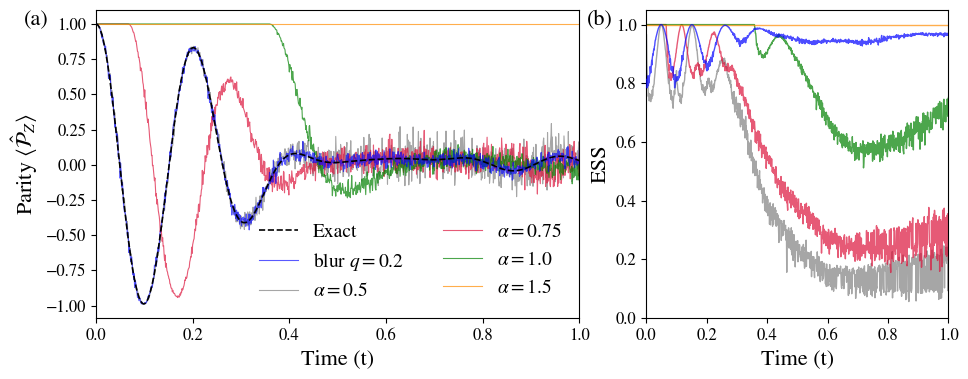

In [8]:
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
N, alpha_rbm, n_samples = 8, 4, 2**12
# times_exact, parity_exact = run_ed(N, h=1.0, J=1.0, T=2.0)

fig = plt.figure(figsize=(11, 4.0))
gs = fig.add_gridspec(1, 2, wspace=0.17, width_ratios=[1.6, 1])
ax_z = fig.add_subplot(gs[0])
ax_ess = fig.add_subplot(gs[1])

# ax_inset = ax_z.inset_axes([0.5, 0.15, 0.35, 0.25])
colors = ['grey', 'crimson', 'green', 'darkorange']
t = 1.75
# inset_xlim = [0.0, 0.1]
# inset_ylim = [0.9, 1.05]



n_samples = 2**10
N = 16
T = 1.0
h = 1.0


ax_z.plot(times_exact, np.real(parity_exact), "k--", lw=1.2, label="Exact",zorder = 10)

for i, q in enumerate([0.2]):
    # cold start
    sp = f"./data/TFIM_PFAFF_{N}_parity/blur_{n_samples}_h_{h:1.3f}_q_{q:1.3f}_T_{T:1.3f}/"
    print(sp)
    lg = Logger(path=sp, fields=fields_to_track)
    if lg.restore():
        ts = np.array(lg.data["t"]["values"])
        par = np.array(lg.data["parity"]["Mean"]).real
        ess = np.array(lg.data["ess_bridge"]["values"])
        ax_z.plot(ts, par, color="b", label=fr"blur $q={q}$",lw=0.8,alpha=0.65,zorder = 9)
        ax_ess.plot(ts, ess, color="b", label=fr"blur $ q={q}$ ",lw=1,alpha=0.7,zorder = 9)

for i, a in enumerate([0.5,0.75,1.0,1.5]):
    # cold start
    sp = f"./data/TFIM_PFAFF_{N}_parity/overdispersed_{n_samples}_h_{h:1.3f}_alpha_{a:1.3f}_T_{T:1.3f}/"
    print(sp)
    lg = Logger(path=sp, fields=fields_to_track)
    if lg.restore():
        ts = np.array(lg.data["t"]["values"])
        par = np.array(lg.data["parity"]["Mean"]).real
        par = np.array(lg.data["parity_overdispersed"]["values"]).real
        ess = np.array(lg.data["ess_bridge"]["values"])
        ax_z.plot(ts, par, color=colors[i], label=fr"$\alpha={a}$",lw=0.8,alpha=0.7)
        # ax_inset.plot(ts, par, color=colors[i],lw=1)
        ax_ess.plot(ts, ess, color=colors[i], label=fr"$\alpha={a}$",lw=1,alpha=0.7)
        


ax_z.set_xlabel("Time (t)", fontsize=16)
ax_z.set_ylabel(r"Parity $\langle \hat{\mathcal{P}}_Z\rangle$", fontsize=16)
ax_z.legend(fontsize=14, frameon=False,ncols=2)


ax_ess.set_xlabel("Time (t)", fontsize=16)
ax_ess.set_ylabel("ESS", fontsize=16)
ax_ess.set_ylim([0, 1.05])

ax_z.set_xlim(0,1)
ax_ess.set_xlim(0,1)

loc_x = -0.15
loc_y = 0.95
ax_z.annotate("(a)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=16)
ax_ess.annotate("(b)", xy=(1.3*loc_x, loc_y), xycoords="axes fraction", fontsize=16)
ax_z.tick_params(axis='both', which='major', labelsize=12)
ax_ess.tick_params(axis='both', which='major', labelsize=12)
plt.savefig("Fig5_overdispersed.pdf", bbox_inches="tight", pad_inches=0.01)
plt.show()
